In [36]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr
import numpyro
import os
import numpyro.distributions as dist

from model import (
    MiniGPJax,
    # kernel / mean / likelihood classes
    RBF, Matern32, GaussianLikelihood, ZeroMean, GPParams, Standardizer,
    # state (de)serializers defined in your file
    _kernel_to_state, _kernel_from_state,
    _lik_to_state, _lik_from_state,
    _zeromean_to_state, _zeromean_from_state,
    _gpparams_to_state, _gpparams_from_state,
    _std_to_state, _std_from_state,
)
from model import MiniGPJax, _register_all_serializers_once
_register_all_serializers_once()

from numpyro.infer import MCMC, NUTS, init_to_median
import jax.random as jr
import jax.numpy as jnp


In [2]:
TRAIN_CSV = "Completed_Train_set_3.csv" #Completed_train_set_10_30_25.csv#"Train_Set_2.csv"
TEST_CSV  = "Completed_Test_set_3.csv"#"Test_Set_2.csv"
CKPT_DIR  = "ckpts/gp_run_007"
dim = 5
gp = MiniGPJax(
    dim=dim,
    kernel="rbf",            # or "matern32" I dont have the others
    fixed_noise=None,        # consider None to learn noise for better generalization
    standardize_x=True,
    standardize_y=True,
    log_y=True,              # ensures: log -> standardize (train stats) -> fit
    jitter=1e-6,
)
gp.load(TRAIN_CSV, TEST_CSV)
gp.fit(lbfgs_max_iter=30, lbfgs_tol=1e-7, num_restarts=2, seed=200)

#

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1768687624.839973 16164111 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1768687624.857977 16164111 service.cc:145] XLA service 0x6000029ec900 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768687624.858151 16164111 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1768687624.859487 16164111 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1768687624.859644 16164111 mps_client.cc:384] XLA backend will use up to 26800209920 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Max
[ok] Loaded train: X=(1024, 5), y=(1024,) (log→std)
[ok] Loaded test:  X=(256, 5), y=(256,) (log→std)
[restart 0] nLML = -1756.754517
[restart 1] nLML = -1756.754517
[ok] Best nLML = -1756.754517
[fit] amp=2.356 | noise_var=2.588e-05 | ell=[5.136 1.915 9.435 0.417 3.39 ]
[fit] train RMSE(z)=0.0040 | R²(z)=1.0000  (z = standardized)


In [3]:
gp.evaluate_and_plot(outdir="1_1_2026")  # defaults to "log" when log_y=True


[eval:log] RMSE(log)=0.036881 | MAE(log)=0.013797 | R²(log)=0.998990


{'rmse_log': 0.03688124939799309,
 'mae_log': 0.013796549290418625,
 'r2_log': 0.9989898231403537}

In [4]:
_register_all_serializers_once()
gp.save_checkpoint(CKPT_DIR)

[save] Wrote checkpoint to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_007


In [5]:
CKPT_DIR = "ckpts/gp_run_007"
TRAIN_CSV = "Completed_Train_set_3.csv"
_register_all_serializers_once()
gp_loaded = MiniGPJax.ready_from_checkpoint(CKPT_DIR, train_csv=TRAIN_CSV, rebuild=True)

[load] Loaded config+params from: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_007
[posterior] Rebuilt training posterior.


## Sanity check


In [6]:
x_single = np.array([[0.6,5500,0.39,7.,4.45E-07]], dtype=np.float32)  # shape (1, 5)

mu, std = gp_loaded.predict(x_single)
print(mu/1e7, std/1e7)

[0.20595287] [0.00180454]


In [7]:
import jax
import jax.numpy as jnp

# cache these once (they are jnp arrays)
x_mean = gp_loaded.std.x_mean   # shape (dim,)
x_std  = gp_loaded.std.x_std    # shape (dim,)

def _gp_predict_mean_from_Xn_std(Xn_std: jnp.ndarray) -> jnp.ndarray:
    """
    Xn_std: (N, dim) already-standardized inputs (same space GP was trained in).
    Returns: (N,) mean prediction in original y units (with lognormal correction if log_y=True).
    """
    # Posterior in z-space (standardized log(y) if log_y=True)
    mean_z, std_z = gp_loaded.posterior.predict(Xn_std, include_noise=False)

    # Undo y-standardization (still log-space if log_y=True)
    mean_z_log, std_z_log = gp_loaded.std.inverse_y(mean_z, std_z)

    return mean_z_log

def gp_single_z(z1, z2, z3, z4, flow_raw):
    """
    z1..z4 are standardized coordinates for x1 to x4 (what NUTS samples).
    flow_raw is in original physical units (whatever you used in training CSV as x5).
    """
    # Standardize the flow dimension to match GP training space
    z5 = (flow_raw - x_mean[4]) / x_std[4]

    Xn_std = jnp.stack([z1, z2, z3, z4, z5])         # (dim,)
    return _gp_predict_mean_from_Xn_std(Xn_std[None, :])[0]

# vectorize over flow values
gp_flow_maps = jax.vmap(gp_single_z, (None, None, None, None, 0))


In [8]:
# physical inputs
x_phys = jnp.array([0.6, 7000.0, 1., 0.01])

# standardize using GP training statistics
z_phys = (x_phys - gp_loaded.std.x_mean[:4]) / gp_loaded.std.x_std[:4]

z1, z2, z3, z4 = z_phys

flows = jnp.array([2.4e-7, 3.45e-7, 8.1e-7])

prins = gp_flow_maps(z1, z2, z3, z4, flows)# / 6894.76
print(prins)


[16.475197 16.66677  17.27877 ]


In [9]:
df = pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Pressure")               
df.head()

subset = df.iloc[1:, 2:6]
# Make the first row the header

new_header = subset.iloc[0]   # get the first row
subset = subset[1:]           # take the data after the header row
subset.columns = new_header   # set header
subset = subset.reset_index(drop=True)  # clean index
print(subset.head())

pressure = subset['Pump Pressure(PSI)'].values[1:]
pressure_times = subset['Time(s)'].values[1:]

1   Time(s) Extruder Pressure (PSI) Pump Pressure(PSI) Temperature(C)
0         0               687.94829         332.927429     279.594642
1  0.060966              721.002479         305.609107     279.594642
2  0.108939              747.514903         285.115698     279.594642
3  0.154912               767.74587         270.662268     279.594642
4  0.200885              781.886558          261.56303     279.594642


(array([1.000e+00, 1.000e+00, 1.119e+03, 7.230e+02, 1.200e+01, 7.800e+01,
        1.363e+03, 4.850e+02, 1.000e+00, 1.000e+00]),
 array([-2.11480363, -1.53596184, -0.95712005, -0.37827827,  0.20056352,
         0.77940531,  1.35824709,  1.93708888,  2.51593067,  3.09477245,
         3.67361424]),
 <BarContainer object of 10 artists>)

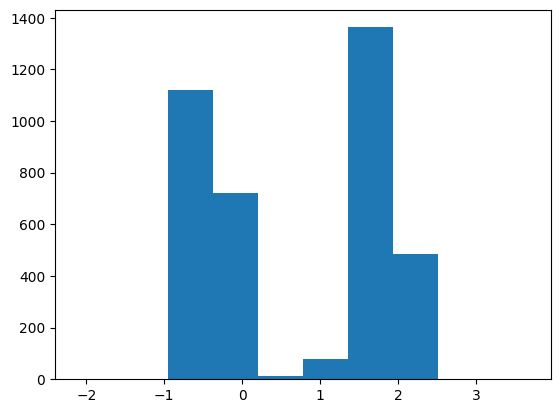

In [10]:
df= pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Position")
df.head()
columns_to_drop = [0, 1,7, 9, 10, 11, 12]

df.drop(df.columns[columns_to_drop], axis=1, inplace=True)


subset = df.iloc[1:, :]
new_header = subset.iloc[0]
subset.columns = new_header
subset = subset.reset_index(drop=True)  # clean index
subset.head()

# xreate all the ararys 

time = subset['Time(seconds)'].values[1:]
x_locs = subset['x(mm)'].values[1:]
y_locs = subset['y(mm)'].values[1:]
z_locs = subset['z(mm)'].values[1:]
speeds = subset['Speed (mm/s)'].values[1:]
flow_rates = subset['Flowrate[m^3/s]'].values[1:]

extract_flow = 2.91582835522733e-07
mask = (flow_rates > 0.96 * extract_flow) & (flow_rates < 1.04 * extract_flow)
plt.hist((flow_rates[np.argwhere(mask)] - extract_flow)/extract_flow * 100)

In [11]:
# cleaned version of my code above from CHATGPT

def middle50_slice(n: int):
    i0 = int(0.25 * n)
    i1 = max(int(0.75 * n), i0 + 1)
    return i0, i1
    
def steady_mean_of_segment(times: np.ndarray, pressures: np.ndarray):
    """mean and standard error from the middle 50% of the time segment."""
    times = np.asarray(times)
    pressures = np.asarray(pressures, dtype=float)

    i0, i1 = middle50_slice(len(pressures))
    x = pressures[i0:i1]

    m = np.mean(x)
    s = np.std(x, ddof=1) if x.size > 1 else np.nan
    se = s / np.sqrt(x.size) if x.size > 1 else np.nan
    return m, se
    
def extract_layer_data(layer: int,
                       layer_height: float,
                       z_locs: np.ndarray,
                       time: np.ndarray,
                       speeds: np.ndarray,
                       flow_rates: np.ndarray,
                       pressure_times: np.ndarray,
                       pressure: np.ndarray,
                       extract_flow: float,
                       flow_sensor_error_percentage: float = 1.0):
    """
    Extracts steady-state flow and corresponding pressure data for a given layer.

    Parameters
    ----------
    layer : int
        Layer number (1-indexed).
    layer_height : float
        Height of one layer in mm.
    z_locs : np.ndarray
        Array of z-locations (same length as `time` and `flow_rates`).
    time : np.ndarray
        Array of timestamps for flow measurements.
    speeds : np.ndarray
        Array of speeds corresponding to each time.
    flow_rates : np.ndarray
        Array of flow rate measurements.
    pressure_times : np.ndarray
        Array of timestamps for pressure measurements.
    pressure : np.ndarray
        Array of pressure values.
    extract_flow : float
        Expected flow rate to extract steady-state region.
    flow_sensor_error_percentage : float, optional
        Allowed sensor error in %, default 5%.

    Returns
    -------
    dict
        Dictionary containing:
        - 'times_speeds': np.ndarray of times during steady-state
        - 'flow_rates_ss': np.ndarray of steady-state flow rates
        - 'pressure_times_ss': np.ndarray of matching pressure times
        - 'pressures_ss': np.ndarray of matching pressure values
        - 'mask_flow_rates': np.ndarray of indices of steady-state flow points
    """

    # Compute allowed flow rate range
    extract_flow_min = extract_flow * (1 - 0.01 * flow_sensor_error_percentage)
    extract_flow_max = extract_flow * (1 + 0.01 * flow_sensor_error_percentage)

    # Extract layer
    mask_layer = np.argwhere(
        (z_locs >= layer_height * (layer - 1)) & (z_locs < layer_height * layer)
    ).flatten()
    times_layer = time[mask_layer]
    speeds_layer = speeds[mask_layer]
    flow_rates_layer = flow_rates[mask_layer]

    # Steady-state flow mask
    mask_flow = np.argwhere(
        (flow_rates_layer >= extract_flow_min) & (flow_rates_layer <= extract_flow_max)
    ).flatten()
    times_speeds = times_layer[mask_flow]
    flow_rates_ss = flow_rates_layer[mask_flow]

    # Matching pressure segment
    if len(times_speeds) > 0:
        time_range = np.array([np.min(times_speeds), np.max(times_speeds)])
        mask_pressure = np.argwhere(
            (pressure_times >= time_range[0]) & (pressure_times <= time_range[1])
        ).flatten()
        pressure_times_ss = pressure_times[mask_pressure]
        pressures_ss = pressure[mask_pressure]
    else:
        pressure_times_ss = np.array([])
        pressures_ss = np.array([])

    return {
        "times_speeds": times_speeds,
        "flow_rates_ss": flow_rates_ss,
        "pressure_times_ss": pressure_times_ss,
        "pressures_ss": pressures_ss,
        "mask_flow_rates": mask_flow,
    }

In [19]:
flows = np.array([
    2.91582835522733e-07,
    4.84503201019647e-07,
    6.87113630536953e-07,
    8.89724060054260e-07,
], dtype=np.float32)

# ---------- collect per-layer steady means ----------
n_layers = 14
means = np.full((n_layers, 4), np.nan)
sems  = np.full((n_layers, 4), np.nan)

# NEW: store per-layer average measured flow for each of the 4 flow setpoints
flow_means = np.full((n_layers, 4), np.nan)
flow_sems  = np.full((n_layers, 4), np.nan)

def pick_first_key(d: dict, candidates):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return None

for layer in range(1, n_layers + 1):
    for k, flow in enumerate(flows):
        res = extract_layer_data(
            layer=layer,
            layer_height=1.5,
            z_locs=z_locs,
            time=time,
            speeds=speeds,
            flow_rates=flow_rates,
            pressure_times=pressure_times,
            pressure=pressure,
            extract_flow=flow,
            flow_sensor_error_percentage=4.0,
        )

        # ----- pressure steady-state stats (existing) -----
        pt = res["pressure_times_ss"]
        pv = res["pressures_ss"]
        m, se = steady_mean_of_segment(pt, pv)
        means[layer-1, k] = m
        sems[layer-1, k]  = se

        # ----- flow steady-state stats (NEW) -----
        # Try to read steady-state flow directly if provided by extract_layer_data
        ft = pick_first_key(res, ["flow_times_ss", "flowrate_times_ss", "flow_rate_times_ss"]) or pt
        fv = pick_first_key(res, ["flow_rates_ss", "flowrate_ss", "flows_ss", "flow_ss"])

        if fv is None:
            # Fallback: estimate from the raw flow_rates around the commanded flow ± sensor error,
            # within the same time indices used for pressure steady-state, if available.
            # Try to get the boolean mask / indices for the steady window:
            mask_ss = pick_first_key(res, ["mask_ss", "steady_mask", "ss_mask"])
            if mask_ss is not None and mask_ss.shape == flow_rates.shape:
                cand = flow_rates[mask_ss]
            else:
                # last-resort: just band around the setpoint across all samples
                band = 0.04 * flow
                mask = (flow_rates > (flow - band)) & (flow_rates < (flow + band))
                cand = flow_rates[mask]

            if cand.size > 1:
                fm, fse = float(np.mean(cand)), float(np.std(cand, ddof=1) / np.sqrt(cand.size))
            elif cand.size == 1:
                fm, fse = float(cand[0]), np.nan
            else:
                fm, fse = np.nan, np.nan
        else:
            # We have steady-state flow vector fv (and possibly its times ft)
            fm, fse = steady_mean_of_segment(ft, fv)

        flow_means[layer-1, k] = fm
        flow_sems[layer-1, k]  = fse

# # ---------- consecutive differences & error propagation (unchanged) ----------
# d12 = means[:, 1] - means[:, 0]
# d23 = means[:, 2] - means[:, 1]
# d34 = means[:, 3] - means[:, 2]

# sd12 = np.sqrt(sems[:, 1]**2 + sems[:, 0]**2)
# sd23 = np.sqrt(sems[:, 2]**2 + sems[:, 1]**2)
# sd34 = np.sqrt(sems[:, 3]**2 + sems[:, 2]**2)

# layers = np.arange(1, n_layers + 1)

# # ---------- plot (unchanged) ----------
# fig, ax = plt.subplots(figsize=(8, 4.8))
# ax.errorbar(layers, d12, yerr=sd12, fmt='o-', capsize=3, label=r'$\Delta 12$: F2 - F1')
# ax.errorbar(layers, d23, yerr=sd23, fmt='s-', capsize=3, label=r'$\Delta 23$: F3 - F2')
# ax.errorbar(layers, d34, yerr=sd34, fmt='^-', capsize=3, label=r'$\Delta 34$: F4 - F3')

# for d, name, ls in [(d12, r'$\Delta 12$ mean', ':'), (d23, r'$\Delta 23$ mean', '--'), (d34, r'$\Delta 34$ mean', '-.')]:
#     mu = np.nanmean(d)
#     ax.axhline(mu, linestyle=ls, alpha=0.4, label=fr'{name} = {mu:.3f}')

# ax.set_xlabel('Layer', fontsize=12)
# ax.set_ylabel('Pressure difference', fontsize=12)
# ax.set_title('Consecutive flow-rate pressure differences across layers', fontsize=13)
# ax.legend(ncol=2)
# ax.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# # ---------- quick numeric summary (unchanged) ----------
# def summarize(name, d, sd):
#     valid = np.isfinite(d)
#     mu = np.nanmean(d)
#     sdv = np.nanstd(d, ddof=1)
#     print(f"{name}: mean={mu:.4f}, std_across_layers={sdv:.4f}, "
#           f"n={valid.sum()}, median_SE={np.nanmedian(sd):.4f}")

# summarize(r"\Delta 12", d12, sd12)
# summarize(r"\Delta 23", d23, sd23)
# summarize(r"\Delta 34", d34, sd34)

# # ---------- NEW: per-layer average flow arrays ----------

f1, f2, f3, f4 = (flow_means[:, 0], flow_means[:, 1], flow_means[:, 2], flow_means[:, 3])

In [20]:
import numpy as np
import pandas as pd

PSI_TO_PA = 6894.76
PA_TO_PSI = 1.0 / PSI_TO_PA

# -----------------------------
# AFTER your per-layer loop fills:
#   means, sems  (pressures in PSI, since 'pressure' is in PSI)
#   flow_means, flow_sems (flows)
# -----------------------------

# Absolute pressures per flow setpoint (PSI)
p1_psi = means[:, 0]
p2_psi = means[:, 1]
p3_psi = means[:, 2]
p4_psi = means[:, 3]

# Standard errors (PSI)
sp1_psi = sems[:, 0]
sp2_psi = sems[:, 1]
sp3_psi = sems[:, 2]
sp4_psi = sems[:, 3]

# Absolute pressures in Pa
p1_pa = p1_psi * PSI_TO_PA
p2_pa = p2_psi * PSI_TO_PA
p3_pa = p3_psi * PSI_TO_PA
p4_pa = p4_psi * PSI_TO_PA

# Standard errors in Pa
sp1_pa = sp1_psi * PSI_TO_PA
sp2_pa = sp2_psi * PSI_TO_PA
sp3_pa = sp3_psi * PSI_TO_PA
sp4_pa = sp4_psi * PSI_TO_PA

# -----------------------------
# Differences (PSI) — same as your existing code
# -----------------------------
d12_psi = p2_psi - p1_psi
d23_psi = p3_psi - p2_psi
d34_psi = p4_psi - p3_psi

sd12_psi = np.sqrt(sp2_psi**2 + sp1_psi**2)
sd23_psi = np.sqrt(sp3_psi**2 + sp2_psi**2)
sd34_psi = np.sqrt(sp4_psi**2 + sp3_psi**2)

# Differences in Pa
d12_pa = d12_psi * PSI_TO_PA
d23_pa = d23_psi * PSI_TO_PA
d34_pa = d34_psi * PSI_TO_PA

sd12_pa = sd12_psi * PSI_TO_PA
sd23_pa = sd23_psi * PSI_TO_PA
sd34_pa = sd34_psi * PSI_TO_PA

# -----------------------------
# Build a clean dataframe with everything
# -----------------------------
layers = np.arange(1, n_layers + 1)

out = pd.DataFrame({
    "layer": layers,

    # flows (what you already computed)
    "flow1_mean_m3s": flow_means[:, 0],
    "flow2_mean_m3s": flow_means[:, 1],
    "flow3_mean_m3s": flow_means[:, 2],
    "flow4_mean_m3s": flow_means[:, 3],
    "flow1_se_m3s": flow_sems[:, 0],
    "flow2_se_m3s": flow_sems[:, 1],
    "flow3_se_m3s": flow_sems[:, 2],
    "flow4_se_m3s": flow_sems[:, 3],

    # absolute pressures (psi)
    "p1_psi": p1_psi, "p1_se_psi": sp1_psi,
    "p2_psi": p2_psi, "p2_se_psi": sp2_psi,
    "p3_psi": p3_psi, "p3_se_psi": sp3_psi,
    "p4_psi": p4_psi, "p4_se_psi": sp4_psi,

    # absolute pressures (Pa)
    "p1_pa": p1_pa, "p1_se_pa": sp1_pa,
    "p2_pa": p2_pa, "p2_se_pa": sp2_pa,
    "p3_pa": p3_pa, "p3_se_pa": sp3_pa,
    "p4_pa": p4_pa, "p4_se_pa": sp4_pa,

    # differences (psi)
    "d12_psi": d12_psi, "d12_se_psi": sd12_psi,
    "d23_psi": d23_psi, "d23_se_psi": sd23_psi,
    "d34_psi": d34_psi, "d34_se_psi": sd34_psi,

    # differences (Pa)
    "d12_pa": d12_pa, "d12_se_pa": sd12_pa,
    "d23_pa": d23_pa, "d23_se_pa": sd23_pa,
    "d34_pa": d34_pa, "d34_se_pa": sd34_pa,
})

# -----------------------------
# Save to disk
# -----------------------------
out_path = "processed_layer_pressures_and_differences.csv"
out.to_csv(out_path, index=False)
print(f"[ok] saved: {out_path}")
print(out.head())


[ok] saved: processed_layer_pressures_and_differences.csv
   layer  flow1_mean_m3s  flow2_mean_m3s  flow3_mean_m3s  flow4_mean_m3s  \
0      1    2.936272e-07    4.893002e-07    6.850937e-07    8.812127e-07   
1      2    2.936769e-07    4.894461e-07    6.848552e-07    8.803803e-07   
2      3    2.936450e-07    4.893212e-07    6.850895e-07    8.812222e-07   
3      4    2.936458e-07    4.894263e-07    6.848264e-07    8.804088e-07   
4      5    2.936463e-07    4.893279e-07    6.850890e-07    8.812594e-07   

   flow1_se_m3s  flow2_se_m3s  flow3_se_m3s  flow4_se_m3s      p1_psi  ...  \
0  2.539022e-10  5.332308e-10  8.972141e-10  2.000338e-09  229.162703  ...   
1  2.651728e-10  5.341661e-10  8.989805e-10  1.924441e-09  221.126100  ...   
2  2.531826e-10  4.843015e-10  8.919628e-10  1.915984e-09  205.536861  ...   
3  2.653207e-10  5.606945e-10  8.947217e-10  1.935696e-09  192.631382  ...   
4  2.652368e-10  5.542144e-10  9.206466e-10  1.977344e-09  202.656297  ...   

      d23_psi  d

In [21]:
F = jnp.concatenate([f1[:, None],f2[:, None],f3[:, None],f4[:, None]], axis =1)

P_pa = jnp.concatenate([p1_pa[:, None], p2_pa[:, None], p3_pa[:, None], p4_pa[:, None]], axis=1)

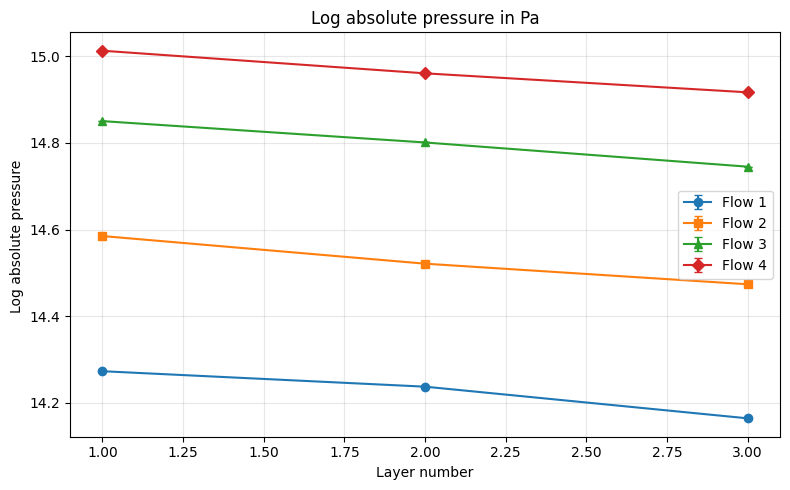

In [117]:
L = 3

plt.figure(figsize=(8, 5))

plt.errorbar(layers[:L], np.log(p1_pa)[:L], yerr=0., fmt="o-", capsize=3, label="Flow 1")
plt.errorbar(layers[:L], np.log(p2_pa)[:L], yerr=0., fmt="s-", capsize=3, label="Flow 2")
plt.errorbar(layers[:L], np.log(p3_pa)[:L], yerr=0., fmt="^-", capsize=3, label="Flow 3")
plt.errorbar(layers[:L], np.log(p4_pa)[:L], yerr=0., fmt="D-", capsize=3, label="Flow 4")

plt.xlabel("Layer number")
plt.ylabel("Log absolute pressure ")
plt.title("Log absolute pressure in Pa")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [118]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp

def model_calibrate_abslog_multiflow_constbias_perflow(F, y_log_pa, x_mean, x_std, L=9):
    N, K = F.shape

    # --- PHYSICAL priors (less skew) ---
    x1_phys = numpyro.sample("x1_phys",
        dist.TruncatedNormal(loc=0.6, scale=0.12, low=0.34, high=0.9)
    )
    x2_phys = numpyro.sample("x2_phys",
        dist.TruncatedNormal(loc=4000.0, scale=1500.0, low=1e3, high=1e4)
    )
    x3_phys = numpyro.sample("x3_phys",
        dist.TruncatedNormal(loc=1.0, scale=1.5, low=1e-3, high=10.0)
    )

    log_x4 = numpyro.sample("log_x4_phys", dist.Uniform(jnp.log(1e-2), jnp.log(12.0)))
    x4_phys = jnp.exp(log_x4)
    numpyro.deterministic("x4_phys", x4_phys)

    # z-mapping for GP
    z1 = (x1_phys - x_mean[0]) / x_std[0]
    z2 = (x2_phys - x_mean[1]) / x_std[1]
    z3 = (x3_phys - x_mean[2]) / x_std[2]
    z4 = (x4_phys - x_mean[3]) / x_std[3]

    numpyro.deterministic("z1", z1)
    numpyro.deterministic("z2", z2)
    numpyro.deterministic("z3", z3)
    numpyro.deterministic("z4", z4)

    MU = jnp.stack([gp_flow_maps(z1, z2, z3, z4, F[:, j]) for j in range(K)], axis=1)

    sigma = numpyro.sample("sigma", dist.HalfNormal(0.3).expand([K]))
    numpyro.sample("y", dist.Normal(MU, sigma), obs=y_log_pa)


In [119]:
import jax.numpy as jnp
import jax.random as jr
from numpyro.infer import MCMC, NUTS, init_to_median

def run_nuts_calibration_abslog_constantbias(
    F, P_pa,
    gp_loaded,
    seed=111, warmup=300, samples=5000, chains=2,
    target_accept=0.75, max_tree_depth=10,
):
    # Convert absolute pressure in Pa -> log(Pa)
    y_log_pa = jnp.log(P_pa)

    # GP standardizer stats (pass into model)
    x_mean = jnp.asarray(gp_loaded.std.x_mean)
    x_std  = jnp.asarray(gp_loaded.std.x_std)

    kernel = NUTS(
        model_calibrate_abslog_multiflow_constbias_perflow,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
        dense_mass=False,
    )

    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",
        progress_bar=True,
    )

    key = jr.PRNGKey(seed)

    # order must match model signature: (F, y_log_pa, x_mean, x_std, L=9)

    mcmc.run(key, F, y_log_pa, x_mean, x_std)

    mcmc.print_summary()
    return mcmc


In [120]:
L = 3  # only use till layer 9 
mcmc = run_nuts_calibration_abslog_constantbias(
    F[:L, :],
    P_pa[:L, :],
    gp_loaded=gp_loaded,
)
samples = mcmc.get_samples()


sample: 100%|███████████████████████████████████████████████████████| 5300/5300 [00:45<00:00, 117.23it/s, 127 steps of size 4.84e-02. acc. prob=0.50]


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
  log_x4_phys      0.91      1.32      1.23     -0.77      2.48    434.50      1.00
     sigma[0]      0.10      0.07      0.08      0.03      0.18   1493.22      1.00
     sigma[1]      0.10      0.07      0.08      0.03      0.19   1060.84      1.00
     sigma[2]      0.09      0.06      0.07      0.03      0.17   2702.30      1.00
     sigma[3]      0.09      0.07      0.07      0.02      0.17   1351.62      1.00
      x1_phys      0.63      0.06      0.64      0.53      0.72    579.13      1.00
      x2_phys   3171.85   1156.76   3124.81   1093.73   4721.56    884.71      1.00
      x3_phys      1.61      1.09      1.47      0.01      3.13    853.88      1.00

Number of divergences: 735


In [121]:

def save_physical_posteriors(samples, folder="Posterior_samples"):
    os.makedirs(folder, exist_ok=True)

    # ---- Save raw arrays directly ----
    keys = ["x1_phys", "x2_phys", "x3_phys", "x4_phys", "sigma"]

    for k in keys:
        if k in samples:
            np.save(os.path.join(folder, f"{k}.npy"), samples[k])

    # ---- Build a full table including ALL sigmas ----
    df = pd.DataFrame({
        "x1_phys": samples["x1_phys"],
        "x2_phys": samples["x2_phys"],
        "x3_phys": samples["x3_phys"],
        "x4_phys": samples["x4_phys"],
    })

    # Expand sigma dimensions into columns: sigma_0 ... sigma_{K-1}
    sig = samples["sigma"]
    if sig.ndim == 2:
        for j in range(sig.shape[1]):
            df[f"sigma_{j}"] = sig[:, j]
    else:
        df["sigma"] = sig

    df.to_csv(os.path.join(folder, "posterior_physical_params_full_3Layers.csv"), index=False)

    # ---- Summary stats ----
    summary = df.describe(percentiles=[0.05, 0.5, 0.95])
    summary.to_csv(os.path.join(folder, "posterior_summary.csv"))

    print(f"Saved full posterior (including all sigmas) to: {os.path.abspath(folder)}")


In [122]:
save_physical_posteriors(samples)

Saved full posterior (including all sigmas) to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/Posterior_samples


# Traces


In [88]:
def plot_scalar_traces(samples, names):
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 2.2 * len(names)), sharex=True)

    if len(names) == 1:
        axes = [axes]

    for i, name in enumerate(names):
        axes[i].plot(samples[name], alpha=0.6)
        axes[i].set_ylabel(name)
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("MCMC iteration")
    plt.tight_layout()
    plt.show()


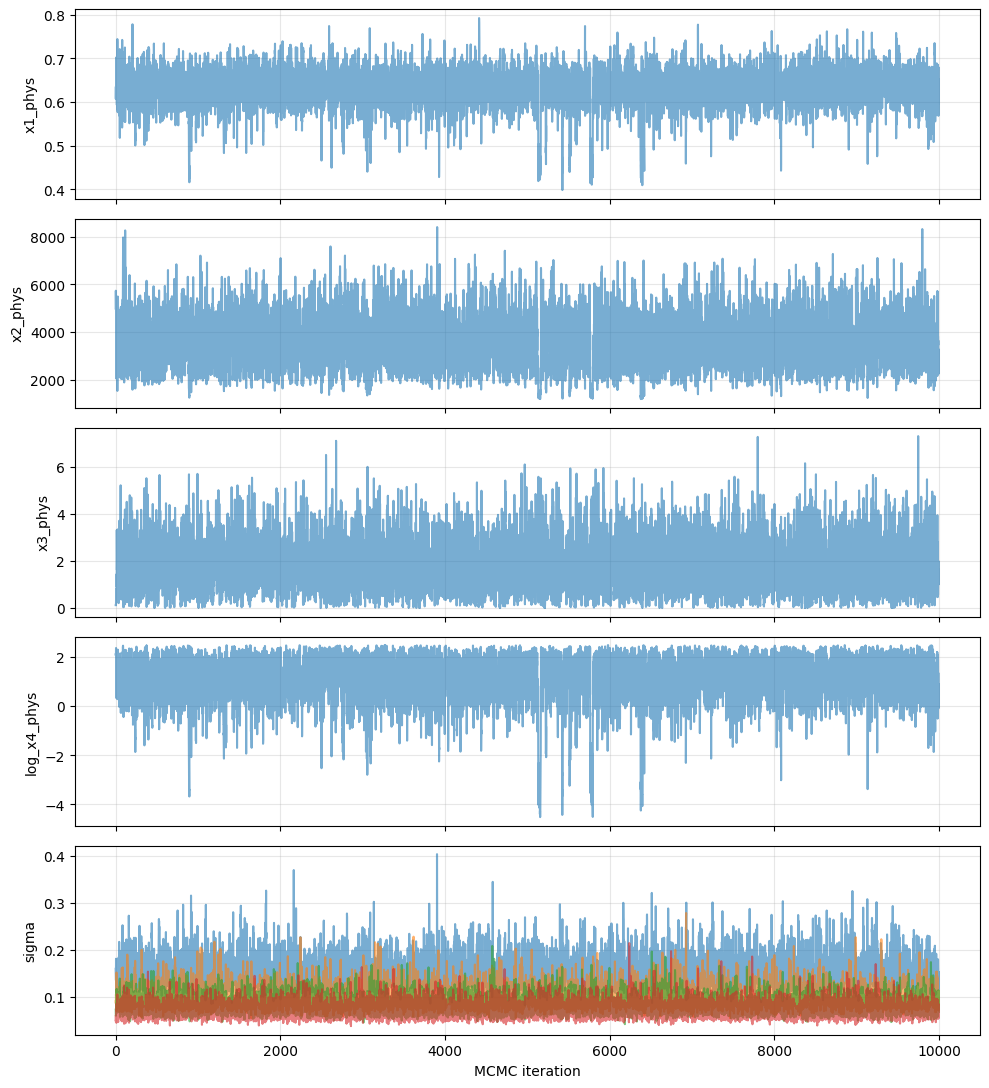

In [89]:
plot_scalar_traces(
    samples,
    names=(
        "x1_phys",        # n
        "x2_phys",    # mu_0 (log)
        "x3_phys",    # mu_inf (log)
        "log_x4_phys",    # lambda (log)
        "sigma",
    )
)


## prios vs posteriors


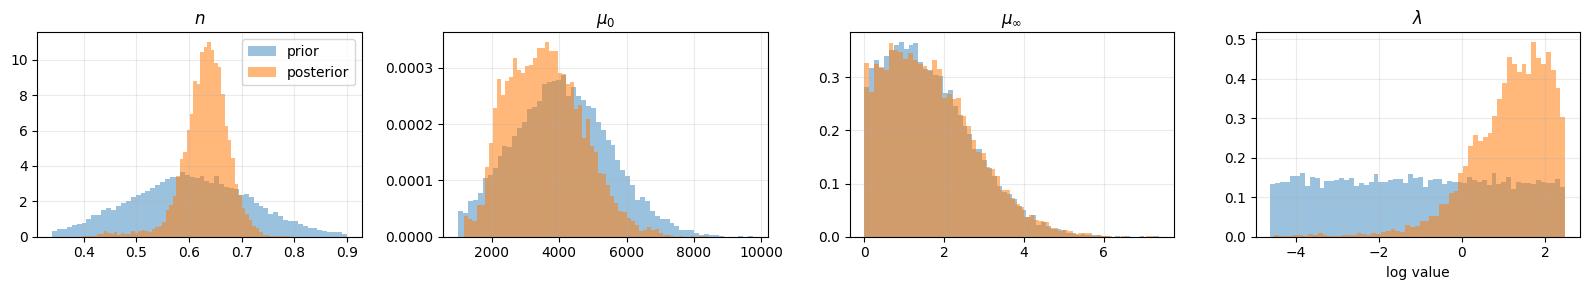

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# -------- Prior sampler consistent with YOUR latest model --------
def sample_priors_latest_truncnorm(n=20000, seed=0):
    rng = np.random.default_rng(seed)
    prior = {}

    # x1_phys ~ TruncatedNormal(loc=0.6, scale=0.12, low=0.34, high=0.9)
    mu, sig, low, high = 0.6, 0.12, 0.34, 0.9
    a, b = (low - mu) / sig, (high - mu) / sig
    prior["x1_phys"] = truncnorm.rvs(a, b, loc=mu, scale=sig, size=n, random_state=rng)

    # x2_phys ~ TruncatedNormal(loc=4000, scale=1500, low=1e3, high=1e4)
    mu, sig, low, high = 4000.0, 1500.0, 1e3, 1e4
    a, b = (low - mu) / sig, (high - mu) / sig
    prior["x2_phys"] = truncnorm.rvs(a, b, loc=mu, scale=sig, size=n, random_state=rng)

    # x3_phys ~ TruncatedNormal(loc=1.0, scale=1.5, low=1e-3, high=10)
    mu, sig, low, high = 1.0, 1.5, 1e-3, 10.0
    a, b = (low - mu) / sig, (high - mu) / sig
    prior["x3_phys"] = truncnorm.rvs(a, b, loc=mu, scale=sig, size=n, random_state=rng)

    # log_x4_phys ~ Uniform(log(1e-2), log(12)); x4_phys = exp(log_x4_phys)
    prior["log_x4_phys"] = rng.uniform(np.log(1e-2), np.log(12.0), size=n)
    prior["x4_phys"] = np.exp(prior["log_x4_phys"])

    return prior


# -------- Pull posterior physical params --------
def get_post_phys_latest(samples):
    post = {}
    post["x1_phys"] = np.asarray(samples["x1_phys"])
    post["x2_phys"] = np.asarray(samples["x2_phys"])
    post["x3_phys"] = np.asarray(samples["x3_phys"])
    post["x4_phys"] = np.asarray(samples["x4_phys"]) if "x4_phys" in samples else np.exp(np.asarray(samples["log_x4_phys"]))
    return post


# -------- Plot prior vs posterior (λ in log space) --------
def plot_prior_vs_posterior_latest(samples, n_prior=20000, seed=0, bins=60):
    prior = sample_priors_latest_truncnorm(n=n_prior, seed=seed)
    post = get_post_phys_latest(samples)

    titles = [r"$n$", r"$\mu_0$", r"$\mu_{\infty}$", r"$\lambda$"]
    keys   = ["x1_phys", "x2_phys", "x3_phys", "x4_phys"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))

    for ax, k, title in zip(axes, keys, titles):
        a = prior[k]
        b = post[k]

        # plot lambda on log scale (more readable)
        if k == "x4_phys":
            a = np.log(a)
            b = np.log(b)
            ax.set_xlabel("log value")

        ax.hist(a, bins=bins, density=True, alpha=0.45, label="prior")
        ax.hist(b, bins=bins, density=True, alpha=0.55, label="posterior")
        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


# ---- Use it ----
plot_prior_vs_posterior_latest(samples, n_prior=20000, seed=0, bins=60)


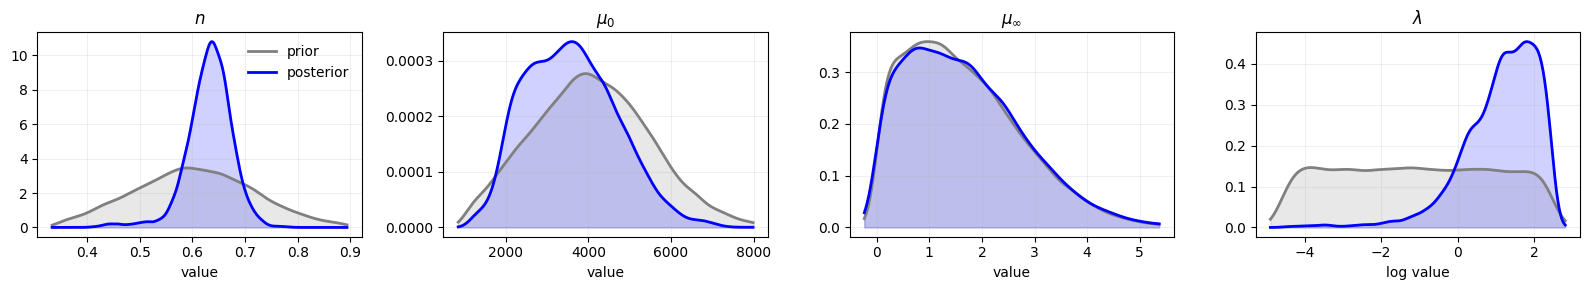

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_prior_vs_posterior_latest_kde(samples, n_prior=20000, seed=0, gridsize=400):
    prior = sample_priors_latest_truncnorm(n=n_prior, seed=seed)
    post  = get_post_phys_latest(samples)

    titles = [r"$n$", r"$\mu_0$", r"$\mu_{\infty}$", r"$\lambda$"]
    keys   = ["x1_phys", "x2_phys", "x3_phys", "x4_phys"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))

    for ax, k, title in zip(axes, keys, titles):
        a = np.asarray(prior[k])
        b = np.asarray(post[k])

        # plot lambda in log space (readable)
        xlabel = "value"
        if k == "x4_phys":
            a = np.log(a)
            b = np.log(b)
            xlabel = "log value"

        # x-range based on combined prior+posterior (robust)
        lo, hi = np.quantile(np.concatenate([a, b]), [0.005, 0.995])
        pad = 0.05 * (hi - lo + 1e-12)
        xgrid = np.linspace(lo - pad, hi + pad, gridsize)

        # KDEs
        kde_a = gaussian_kde(a)
        kde_b = gaussian_kde(b)
        ya = kde_a(xgrid)
        yb = kde_b(xgrid)

        # Prior (gray)
        ax.plot(xgrid, ya, color="gray", linewidth=2, label="prior")
        ax.fill_between(xgrid, 0, ya, color="gray", alpha=0.18)

        # Posterior (blue)
        ax.plot(xgrid, yb, color="blue", linewidth=2, label="posterior")
        ax.fill_between(xgrid, 0, yb, color="blue", alpha=0.18)

        # Add median + 95% interval for posterior (optional but nice)
        q2p5, q50, q97p5 = np.quantile(b, [0.025, 0.5, 0.975])
        #ax.axvline(q50, color="blue", linestyle="-", linewidth=1.5, alpha=0.9)
        #ax.axvline(q2p5, color="blue", linestyle="--", linewidth=1.0, alpha=0.7)
        #ax.axvline(q97p5, color="blue", linestyle="--", linewidth=1.0, alpha=0.7)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.grid(True, alpha=0.20)

    axes[0].legend(frameon=False)
    plt.tight_layout()
    plt.show()


plot_prior_vs_posterior_latest_kde(samples, n_prior=20000, seed=0)


## Summary stat

In [92]:
import numpy as np

def summarize_array(x, name):
    x = np.asarray(x)
    q2p5, q5, q50, q95, q97p5 = np.quantile(x, [0.025, 0.05, 0.5, 0.95, 0.975])
    mean = x.mean()
    std  = x.std(ddof=1)
    xmin, xmax = x.min(), x.max()
    print(
        f"{name:8s}  mean={mean: .6g}  std={std: .6g}  "
        f"median={q50: .6g}  90% CI=[{q5: .6g}, {q95: .6g}]  "
        f"95% CI=[{q2p5: .6g}, {q97p5: .6g}]  min={xmin: .6g}  max={xmax: .6g}"
    )

def summarize_physical_posterior(samples):
    post = get_post_phys_latest(samples)  # uses your helper above
    summarize_array(post["x1_phys"], "x1_phys")
    summarize_array(post["x2_phys"], "x2_phys")
    summarize_array(post["x3_phys"], "x3_phys")
    summarize_array(post["x4_phys"], "x4_phys")
    return post

# ---- run ----
post_phys = summarize_physical_posterior(samples)


x1_phys   mean= 0.631811  std= 0.0438583  median= 0.634964  90% CI=[ 0.562498,  0.69522]  95% CI=[ 0.53013,  0.708401]  min= 0.398659  max= 0.792229
x2_phys   mean= 3585.95  std= 1100.61  median= 3531.34  90% CI=[ 1978.09,  5482.36]  95% CI=[ 1783.37,  5879.4]  min= 1184.04  max= 8405.23
x3_phys   mean= 1.66954  std= 1.11598  median= 1.52309  90% CI=[ 0.157259,  3.7178]  95% CI=[ 0.0747643,  4.19432]  min= 0.0014433  max= 7.29316
x4_phys   mean= 4.37279  std= 3.03139  median= 3.67477  90% CI=[ 0.560911,  10.2233]  95% CI=[ 0.303327,  11.0487]  min= 0.0109264  max= 11.9972


In [93]:
import numpy as np
import matplotlib.pyplot as plt

def hist_with_intervals(x, title, bins=60, logx=False):
    x = np.asarray(x)

    q2p5, q5, q50, q95, q97p5 = np.quantile(x, [0.025, 0.05, 0.5, 0.95, 0.975])

    plt.figure(figsize=(6,3))
    if logx:
        x = x[x > 0]
        bins_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), bins)
        plt.hist(x, bins=bins_edges, density=True, alpha=0.7)
        plt.xscale("log")
    else:
        plt.hist(x, bins=bins, density=True, alpha=0.7)

    for v, ls, lab in [
        (q50, "-",  "median"),
        (q5,  "--", "90% CI"),
        (q95, "--", None),
        (q2p5, ":", "95% CI"),
        (q97p5, ":", None),
    ]:
        plt.axvline(v, linestyle=ls, linewidth=2, label=lab)

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


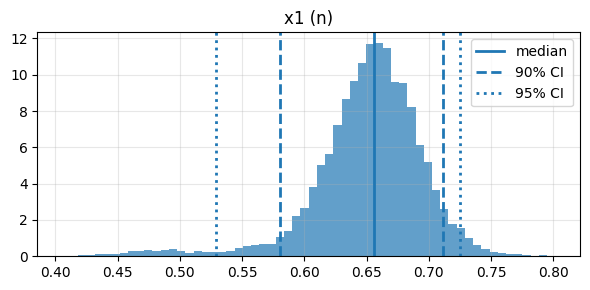

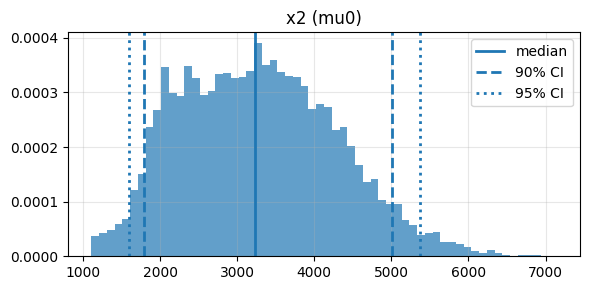

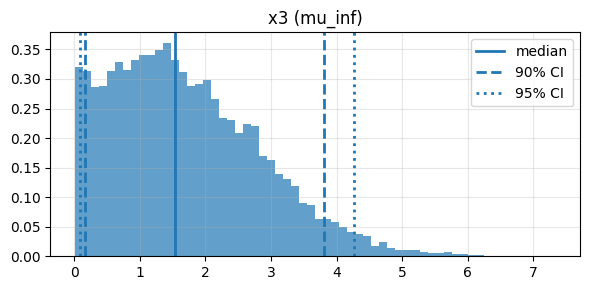

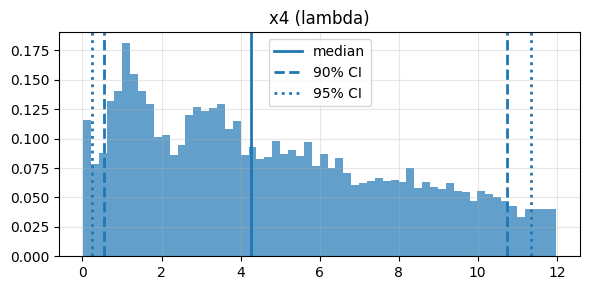

In [94]:
hist_with_intervals(post["x1_phys"], "x1 (n)", logx=False)
hist_with_intervals(post["x2_phys"], "x2 (mu0)", logx=False)
hist_with_intervals(post["x3_phys"], "x3 (mu_inf)", logx=False)  # spans a lot; log helps
hist_with_intervals(post["x4_phys"], "x4 (lambda)", logx=False)


In [95]:
import numpy as np
import matplotlib.pyplot as plt

def interval_plot_single(x, name, logx=False):
    x = np.asarray(x)

    q2p5, q5, q50, q95, q97p5 = np.quantile(x, [0.025, 0.05, 0.5, 0.95, 0.975])
    xmin, xmax = x.min(), x.max()

    plt.figure(figsize=(7, 1.8))

    # horizontal line at y=0
    y = 0

    # min–max
    plt.hlines(y, xmin, xmax, linewidth=2, alpha=0.25)

    # 95% CI
    plt.hlines(y, q2p5, q97p5, linewidth=8, alpha=0.20)

    # 90% CI
    plt.hlines(y, q5, q95, linewidth=8, alpha=0.35)

    # median
    plt.plot(q50, y, "o", markersize=8)

    plt.yticks([])
    plt.xlabel("value")
    plt.title(
        f"{name} posterior: min–max (thin), 95% (light), 90% (dark), median"
    )
    plt.grid(axis="x", alpha=0.25)

    if logx:
        # Only safe if x > 0
        if np.all(x > 0):
            plt.xscale("log")
        else:
            print(f"Warning: {name} has non-positive values; cannot use log scale.")

    plt.tight_layout()
    plt.show()


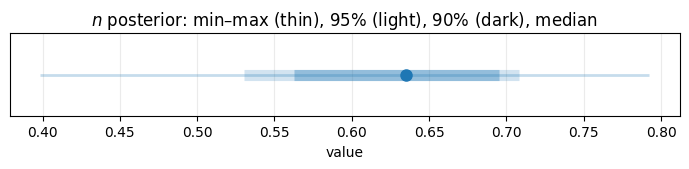

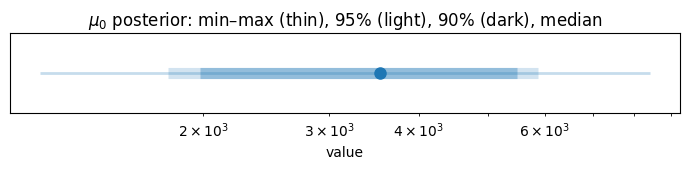

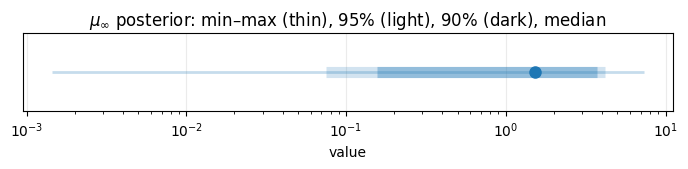

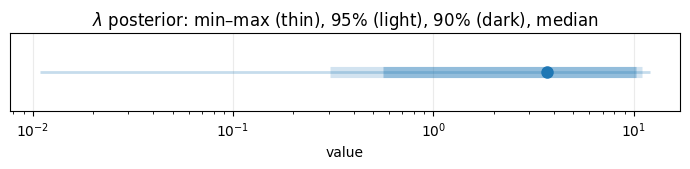

In [96]:
post = get_post_phys_latest(samples)

interval_plot_single(post["x1_phys"], r"$n$", logx=False)
interval_plot_single(post["x2_phys"], r"$\mu_0$", logx=True)
interval_plot_single(post["x3_phys"], r"$\mu_{\infty}$", logx=True)
interval_plot_single(post["x4_phys"], r"$\lambda$", logx=True)


## Pair plots


In [97]:
import numpy as np
import matplotlib.pyplot as plt

def corner_plot(samples_dict, names, transform=None, max_points=5000, bins=40):
    """
    samples_dict: dict name -> 1D array of samples
    names: list of keys in desired order
    transform: dict name -> callable, applied before plotting (e.g., np.log)
    """
    transform = transform or {}

    cols = []
    plot_names = []
    for n in names:
        x = np.asarray(samples_dict[n])
        if n in transform:
            x = transform[n](x)
            plot_names.append(transform.get(f"{n}__label", f"{n}"))
        else:
            plot_names.append(n)
        cols.append(x)

    X = np.column_stack(cols)
    S, D = X.shape

    # thin for speed
    if S > max_points:
        idx = np.random.choice(S, size=max_points, replace=False)
        X = X[idx, :]
        S = max_points

    fig, axes = plt.subplots(D, D, figsize=(2.6 * D, 2.6 * D))

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                ax.hist(X[:, j], bins=bins, density=True, alpha=0.8)
                ax.grid(True, alpha=0.25)
                ax.axvline(X[:, j].mean(), color="k", linestyle="--", linewidth=1)
                ax.axvline(np.median(X[:, j]), color="r", linestyle=":", linewidth=1)

            elif i > j:
                ax.plot(X[:, j], X[:, i], "o", markersize=2, alpha=0.25)
                ax.grid(True, alpha=0.25)

            else:
                ax.axis("off")

            # labels only on outside
            if i == D - 1 and j <= i:
                ax.set_xlabel(plot_names[j])
            else:
                ax.set_xticklabels([])

            if j == 0 and i >= j:
                ax.set_ylabel(plot_names[i])
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    plt.show()



In [98]:
# posterior samples from mcmc
post = mcmc.get_samples()

samples_phys = {
    "$n$": np.asarray(post["x1_phys"]),
    "$\mu_0$": np.asarray(post["x2_phys"]),
    "$\mu_{\infty}$": np.asarray(post["x3_phys"]),
    "$\lambda$": np.asarray(post["x4_phys"]) if "x4_phys" in post else np.exp(np.asarray(post["log_x4_phys"])),
    "log($\lambda$)":np.asarray(post["log_x4_phys"]),
}


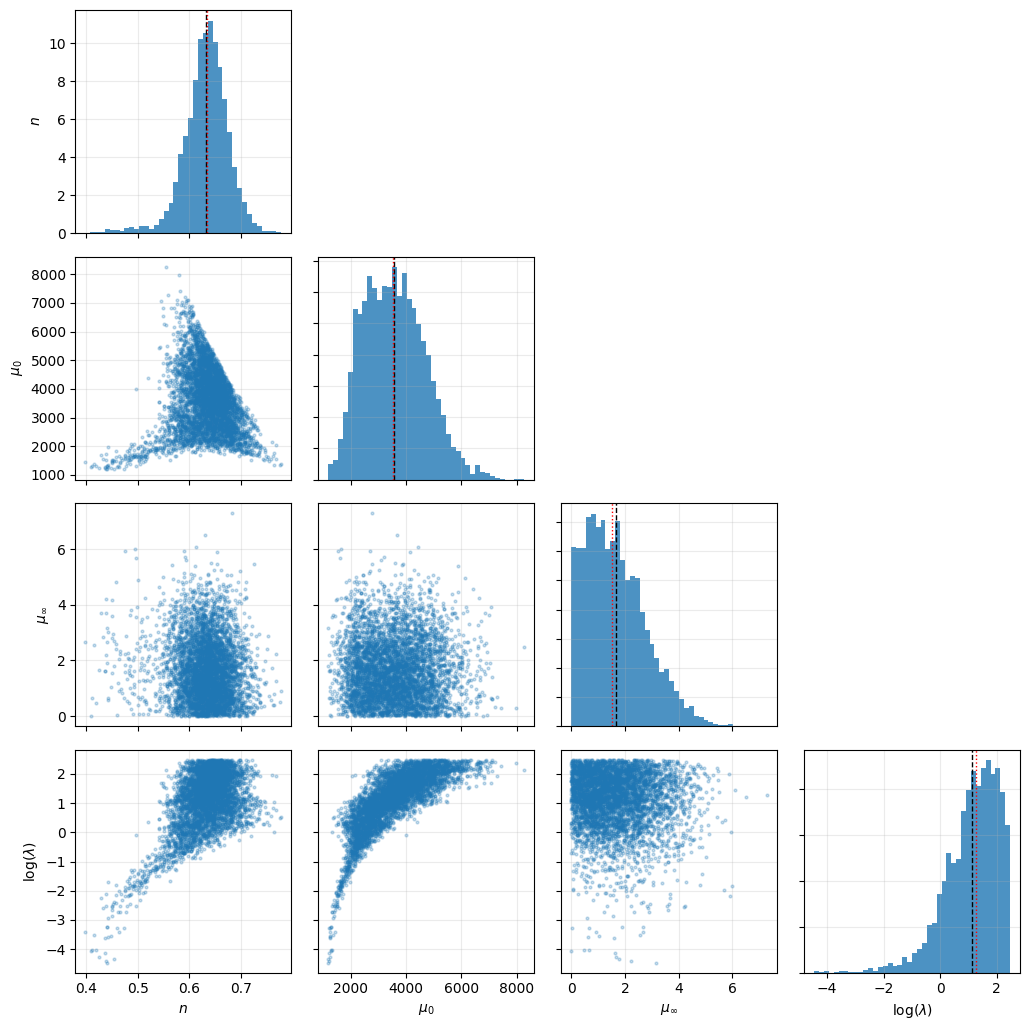

In [99]:
transform = {
    "log($\lambda)$": np.log,
    "x4_phys__label": "log(x4_phys)",
    # Uncomment if x3 spans decades and looks squished:
    # "x3_phys": np.log,
    # "x3_phys__label": "log(x3_phys)",
}

corner_plot(
    samples_phys,
    names=["$n$", "$\mu_0$", "$\mu_{\infty}$", "log($\lambda$)"],
    transform=transform,
    max_points=5000,
    bins=40
)


## PPC

In [100]:
import numpy as np
import matplotlib.pyplot as plt

def posterior_parameter_uncertainty(F, P_pa, layers, samples, gp_flow_maps,
                                    max_draws=2000, seed=0):
    """
    Parameter-only uncertainty:
      MU ~ gp_flow_maps(z1,z2,z3,z4,F)
    Returns:
      layers_np, y_obs, mu_mean, mu_lo, mu_hi   (all in log(Pa))
    Shapes: (N,), (N,K), (N,K), (N,K), (N,K)
    """
    rng = np.random.default_rng(seed)

    F_np = np.asarray(F)
    y_obs = np.log(np.asarray(P_pa))    # (N, K)
    layers_np = np.asarray(layers)

    N, K = F_np.shape

    # Pull posterior draws (deterministics exist in your latest model)
    z1 = np.asarray(samples["z1"])
    z2 = np.asarray(samples["z2"])
    z3 = np.asarray(samples["z3"])
    z4 = np.asarray(samples["z4"])

    S = z1.shape[0]
    n_draws = min(S, max_draws)
    idx = rng.choice(S, size=n_draws, replace=False) if S > n_draws else np.arange(S)

    z1 = z1[idx]; z2 = z2[idx]; z3 = z3[idx]; z4 = z4[idx]

    # Compute MU draws: (n_draws, N, K)
    MU = np.empty((n_draws, N, K), dtype=float)
    for s in range(n_draws):
        for j in range(K):
            MU[s, :, j] = np.asarray(gp_flow_maps(z1[s], z2[s], z3[s], z4[s], F_np[:, j]))

    # Summaries across posterior draws
    mu_mean = MU.mean(axis=0)
    mu_lo   = np.quantile(MU, 0.025, axis=0)
    mu_hi   = np.quantile(MU, 0.975, axis=0)

    return layers_np, y_obs, (mu_mean, mu_lo, mu_hi)


In [101]:
def plot_parameter_uncertainty_per_flow(layers, y_obs, mu_sum, flow_names=None):
    """
    One plot per flow. All quantities are log(Pa).
    Shows ONLY parameter uncertainty (MU band), not likelihood noise.
    """
    mu_mean, mu_lo, mu_hi = mu_sum
    N, K = y_obs.shape

    if flow_names is None:
        flow_names = [f"Flow {j+1}" for j in range(K)]

    for j in range(K):
        plt.figure(figsize=(8, 5))

        # Observations
        plt.plot(layers, y_obs[:, j], "o-", label="Observed", linewidth=1.5)

        # Parameter-only uncertainty band
        plt.plot(layers, mu_mean[:, j], "-", label="Posterior mean μ", linewidth=2)
        plt.fill_between(layers, mu_lo[:, j], mu_hi[:, j], alpha=0.20, label="μ 95% CI (params only)")

        plt.xlabel("Layer number")
        plt.ylabel("Log absolute pressure (Pa)")
        plt.title(f"Parameter Uncertainty Only — {flow_names[j]}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


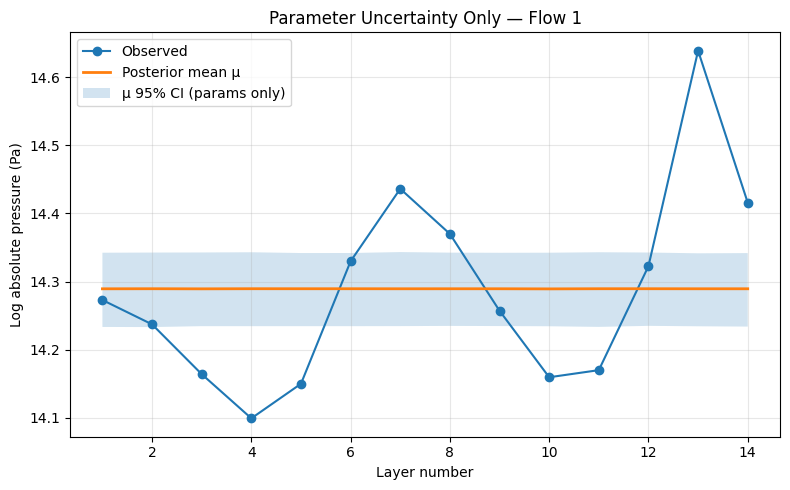

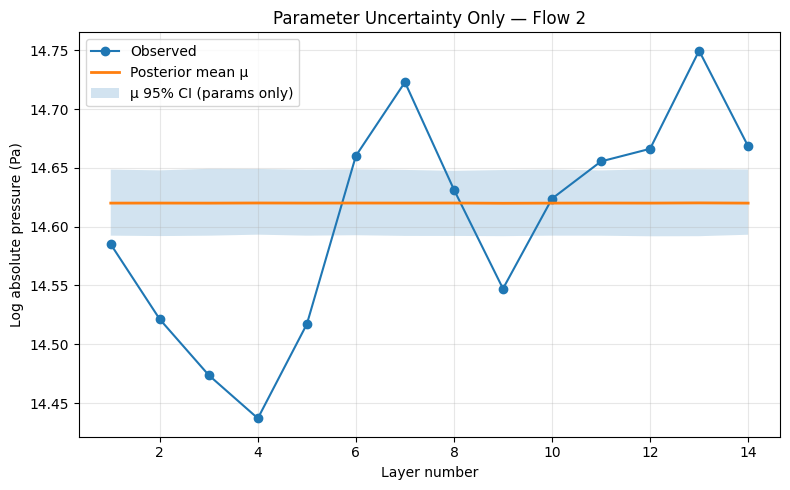

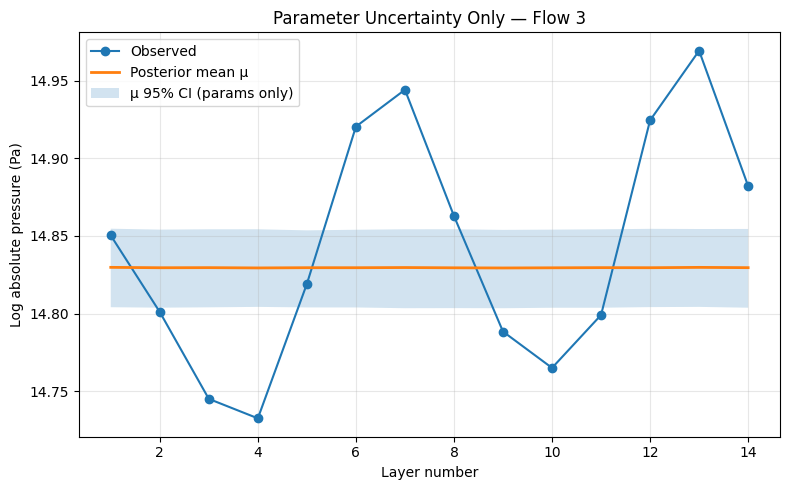

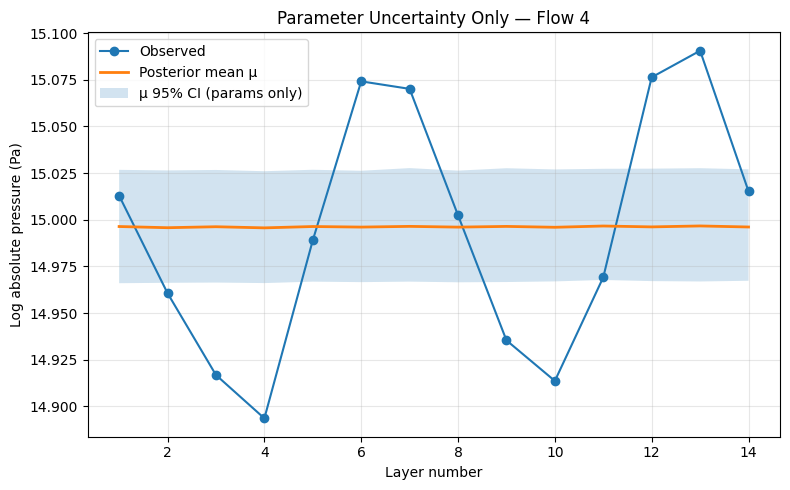

In [102]:
layers_used, y_obs, mu_sum = posterior_parameter_uncertainty(
    F=F[:L, :],
    P_pa=P_pa[:L, :],
    layers=layers[:L],
    samples=samples,
    gp_flow_maps=gp_flow_maps,
    max_draws=2000,
    seed=0
)

plot_parameter_uncertainty_per_flow(
    layers_used, y_obs, mu_sum,
    flow_names=[f"Flow {i+1}" for i in range(y_obs.shape[1])]
)


In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def corner_kde_overlay(
    posts,                       # dict: label -> samples_dict OR array (S,D)
    names,                       # list of variable names in order
    axis_labels=None,            # dict var-> label
    cmap_by_label=None,          # dict label-> cmap name (e.g., "Blues")
    color_by_label=None,         # dict label-> color name (e.g., "blue")
    title=None,
    max_points=4000,
    gridsize=80,
    bins=40,
    diag_fill_alpha=0.20,
    contour_alpha=0.18,
    levels=(0.5, 0.8, 0.95),     # credible-mass contours (approx)
    transforms=None,             # dict var-> callable (e.g., {"x4_phys": np.log})
):
    axis_labels = axis_labels or {}
    cmap_by_label = cmap_by_label or {}
    color_by_label = color_by_label or {}
    transforms = transforms or {}

    def to_matrix(obj):
        # obj can be dict(name->array) or ndarray
        if isinstance(obj, dict):
            X = np.column_stack([np.asarray(obj[n]) for n in names])
        else:
            X = np.asarray(obj)
        # apply transforms columnwise
        for j, n in enumerate(names):
            if n in transforms:
                X[:, j] = transforms[n](X[:, j])
        return X

    def thin(X, max_points):
        S = X.shape[0]
        if S > max_points:
            idx = np.random.choice(S, size=max_points, replace=False)
            return X[idx]
        return X

    # Convert all datasets
    X_by_label = {lab: thin(to_matrix(obj), max_points) for lab, obj in posts.items()}
    D = len(names)

    fig, axes = plt.subplots(D, D, figsize=(2.6 * D, 2.6 * D))
    if title:
        fig.suptitle(title, y=1.01)

    # Helper: pick levels as density thresholds for given mass (approx)
    def kde_levels_from_mass(Z, masses):
        z = Z.ravel()
        z_sorted = np.sort(z)[::-1]
        cumsum = np.cumsum(z_sorted)
        cumsum /= cumsum[-1]
        lvls = []
        for m in masses:
            idx = np.searchsorted(cumsum, m)
            lvls.append(z_sorted[min(idx, len(z_sorted)-1)])
        return sorted(lvls)

    # Determine axis limits per variable across all labels
    allX = np.vstack(list(X_by_label.values()))
    lims = []
    for j in range(D):
        x = allX[:, j]
        lo, hi = np.quantile(x, [0.005, 0.995])
        pad = 0.05 * (hi - lo + 1e-12)
        lims.append((lo - pad, hi + pad))

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # set consistent limits
            ax.set_xlim(*lims[j])
            if i != j:
                ax.set_ylim(*lims[i])

            # labels
            if i == D - 1:
                ax.set_xlabel(axis_labels.get(names[j], names[j]))
            else:
                ax.set_xticklabels([])
            if j == 0 and i != 0:
                ax.set_ylabel(axis_labels.get(names[i], names[i]))
            elif j != 0:
                ax.set_yticklabels([])

            ax.grid(True, alpha=0.15)

            # Diagonal: 1D KDE overlay
            if i == j:
                xgrid = np.linspace(lims[j][0], lims[j][1], gridsize)

                for lab, X in X_by_label.items():
                    color = color_by_label.get(lab, None)
                    kde = gaussian_kde(X[:, j])
                    y = kde(xgrid)

                    ax.plot(xgrid, y, linewidth=2, label=lab, color=color)
                    ax.fill_between(xgrid, 0, y, alpha=diag_fill_alpha, color=color)

                continue

            # Lower triangle: 2D KDE filled contours
            xi = np.linspace(lims[j][0], lims[j][1], gridsize)
            yi = np.linspace(lims[i][0], lims[i][1], gridsize)
            XX, YY = np.meshgrid(xi, yi)
            grid = np.vstack([XX.ravel(), YY.ravel()])

            for lab, X in X_by_label.items():
                cmap = cmap_by_label.get(lab, "Blues")
                color = color_by_label.get(lab, None)

                kde2 = gaussian_kde(np.vstack([X[:, j], X[:, i]]))
                Z = kde2(grid).reshape(gridsize, gridsize)

                lvls = kde_levels_from_mass(Z, levels)
                ax.contourf(XX, YY, Z, levels=lvls + [Z.max()], cmap=cmap, alpha=contour_alpha)
                ax.contour(XX, YY, Z, levels=lvls, colors=color, linewidths=1.2)

    # legend (use first diagonal axis)
    axes[0, 0].legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.show()


In [104]:
posts = {"Posterior": samples_phys}

corner_kde_overlay(
    posts,
    names=["x1_phys","x2_phys","x3_phys","x4_phys"],
    cmap_by_label={"Posterior":"Blues"},
    color_by_label={"Posterior":"blue"},
    axis_labels={
        "x1_phys":"n",
        "x2_phys":r"$\mu_0$",
        "x3_phys":r"$\mu_{\infty}$",
        "x4_phys":r"$\lambda$",
    },
    title="Posterior (physical scale)"
)


KeyError: 'x1_phys'

## effective viscosities


In [105]:
import numpy as np
import matplotlib.pyplot as plt

def mu_bird_carreau(gdot, n, mu0, mu_inf, lam):
    """
    Bird–Carreau (common form):
      mu(gdot) = mu_inf + (mu0 - mu_inf) * (1 + (lam*gdot)^2)^((n-1)/2)
    gdot can be array; params are scalars.
    """
    return mu_inf + (mu0 - mu_inf) * (1.0 + (lam * gdot)**2)**((n - 1.0) / 2.0)


In [112]:
def plot_effective_viscosity_envelope(samples, gdot_min=1e-2, gdot_max=1e2, n_gdot=200,
                                     max_draws=2000, seed=0,
                                     q=(0.05, 0.5, 0.95), title="Posterior effective viscosity"):
    """
    Uses posterior samples of:
      x1_phys = n
      x2_phys = mu0
      x3_phys = mu_inf
      x4_phys = lambda
    Plots mu(gdot) median + band.
    """
    rng = np.random.default_rng(seed)

    # pull posterior (physical)
    n_s   = np.asarray(samples["x1_phys"])
    mu0_s = np.asarray(samples["x2_phys"])
    mui_s = np.asarray(samples["x3_phys"])
    lam_s = np.asarray(samples["x4_phys"]) if "x4_phys" in samples else np.exp(np.asarray(samples["log_x4_phys"]))

    S = len(n_s)
    nd = min(S, max_draws)
    idx = rng.choice(S, size=nd, replace=False) if S > nd else np.arange(S)

    n_s, mu0_s, mui_s, lam_s = n_s[idx], mu0_s[idx], mui_s[idx], lam_s[idx]

    # shear-rate grid
    gdot = np.logspace(np.log10(gdot_min), np.log10(gdot_max), n_gdot)

    # compute viscosity curves: (nd, n_gdot)
    MU = np.empty((nd, n_gdot), dtype=float)
    for s in range(nd):
        MU[s, :] = mu_bird_carreau(gdot, n_s[s], mu0_s[s], mui_s[s], lam_s[s])

    lo, med, hi = np.quantile(MU, q, axis=0)

    plt.figure(figsize=(7, 4))
    plt.plot(gdot, med, linewidth=2, label=f"median (q={q[1]})")
    plt.fill_between(gdot, lo, hi, alpha=0.25, label=f"band (q={q[0]}–{q[2]})")
    plt.xscale("log")
    plt.yscale("log")
    
    plt.xlabel(r"shear rate $\dot\gamma$")
    plt.ylabel(r"viscosity $\mu(\dot\gamma)$")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


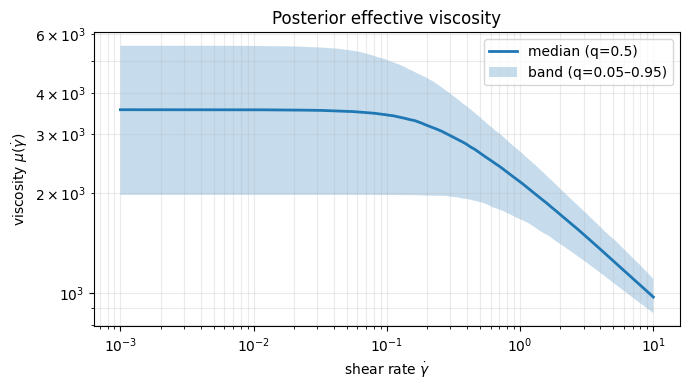

In [116]:
plot_effective_viscosity_envelope(samples, gdot_min=1e-3, gdot_max=1e1, max_draws=2000)
